In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("BBQ.csv")

print(df.head())

    created_utc  score  ...                             url distinguished
0  1.374515e+09    318  ...  http://i.imgur.com/uyi3XPM.jpg           NaN
1  1.359056e+09    255  ...  http://i.imgur.com/qMZEhOb.jpg           NaN
2  1.375234e+09    244  ...  http://i.imgur.com/Wu8VgyO.jpg           NaN
3  1.372098e+09    236  ...        http://imgur.com/a/ltwFv           NaN
4  1.375672e+09    224  ...        http://imgur.com/a/jWiaz           NaN

[5 rows x 22 columns]


In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [6]:
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

if 'text' in df.columns:
    df['clean_text'] = df['text'].apply(preprocess_text)
    print(df[['text', 'clean_text']].head())
else:
    print("'text' column not found")

Columns: ['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups', 'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text', 'over_18', 'thumbnail', 'subreddit_id', 'edited', 'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name', 'url', 'distinguished']
'text' column not found


In [8]:
print(df.columns)
print(df.head())

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')
    created_utc  score  ...                             url distinguished
0  1.374515e+09    318  ...  http://i.imgur.com/uyi3XPM.jpg           NaN
1  1.359056e+09    255  ...  http://i.imgur.com/qMZEhOb.jpg           NaN
2  1.375234e+09    244  ...  http://i.imgur.com/Wu8VgyO.jpg           NaN
3  1.372098e+09    236  ...        http://imgur.com/a/ltwFv           NaN
4  1.375672e+09    224  ...        http://imgur.com/a/jWiaz           NaN

[5 rows x 22 columns]


In [10]:
import numpy as np

X = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [5.0, 8.0]
])

In [12]:
# 1. Imports
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 2. Example DataFrame (replace this with your own df)
data = {
    "text": [
        "I love machine learning",
        "AI is the future",
        "Football is a great sport",
        "Basketball players are tall",
        "Deep learning and AI",
        "Soccer is popular worldwide",
        "Python is great for data science",
        "Tennis is fun to watch"
    ]
}

df = pd.DataFrame(data)

# 3. Vectorize text (convert to numbers)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])

# 4. Apply KMeans clustering
k = 2  # number of clusters (change as needed)
kmeans = KMeans(n_clusters=k, random_state=42)

# 🔥 IMPORTANT: assign clusters to DataFrame
df['cluster'] = kmeans.fit_predict(X)

# 5. View results
print(df)

# 6. Print sample texts from each cluster
for i in range(k):
    print(f"\nCluster {i}:")
    subset = df[df['cluster'] == i]['text']
    
    if subset.empty:
        print("No data in this cluster")
    else:
        print(subset.head(5))

                               text  cluster
0           I love machine learning        0
1                  AI is the future        0
2         Football is a great sport        0
3       Basketball players are tall        0
4              Deep learning and AI        0
5       Soccer is popular worldwide        0
6  Python is great for data science        0
7            Tennis is fun to watch        1

Cluster 0:
0        I love machine learning
1               AI is the future
2      Football is a great sport
3    Basketball players are tall
4           Deep learning and AI
Name: text, dtype: str

Cluster 1:
7    Tennis is fun to watch
Name: text, dtype: str


In [13]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nTop terms for Cluster {i}:")
    center_terms = kmeans.cluster_centers_[i].argsort()[-10:]
    print([terms[ind] for ind in center_terms])


Top terms for Cluster 0:
['popular', 'sport', 'machine', 'football', 'love', 'deep', 'future', 'great', 'learning', 'ai']

Top terms for Cluster 1:
['future', 'football', 'deep', 'data', 'basketball', 'learning', 'worldwide', 'watch', 'fun', 'tennis']


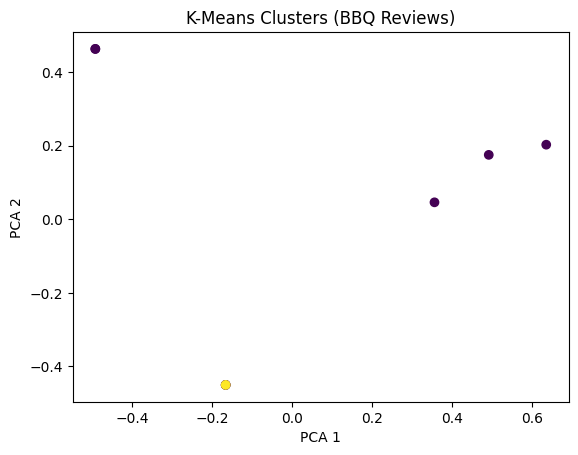

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title("K-Means Clusters (BBQ Reviews)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()